### **Import Library**

In [39]:
import cv2
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt

### **Mount Drive**

In [17]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### **Load Dataset**

Jumlah gambar: 10


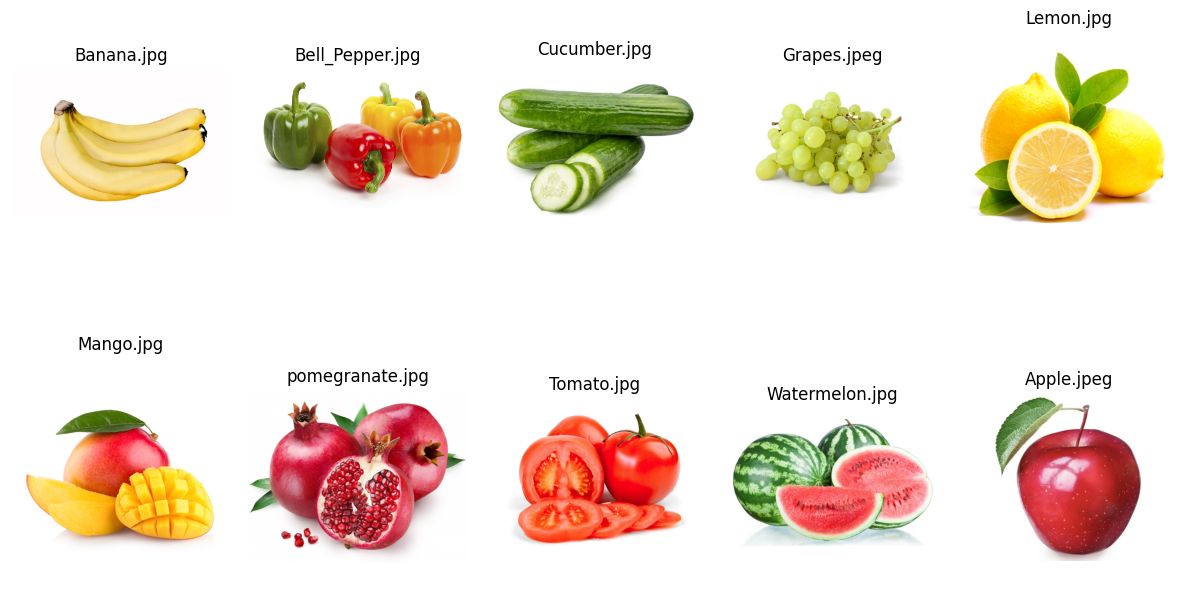

In [18]:
folder_path = "/content/drive/MyDrive/Colab Notebooks/Fruits and Vegetables"

image_files = [f for f in os.listdir(folder_path) if f.endswith(('.jpg','.png','.jpeg'))]

print("Jumlah gambar:", len(image_files))

plt.figure(figsize=(12,8))
for i, file in enumerate(image_files[:10]):  # tampilkan max 10 gambar
    path = os.path.join(folder_path, file)
    image = cv2.imread(path)

    if image is None:
        continue

    # ubah BGR ke RGB (biar warna tidak kebalik)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    plt.subplot(2,5,i+1)
    plt.imshow(image)
    plt.title(file)
    plt.axis('off')

plt.tight_layout()
plt.show()

### **Ekstraksi Fitur Warna (RGB)**

In [19]:
def extract_rgb_features(image):
    R = image[:,:,2]
    G = image[:,:,1]
    B = image[:,:,0]

    mean_r = np.mean(R)
    mean_g = np.mean(G)
    mean_b = np.mean(B)

    return [mean_r, mean_g, mean_b]

In [20]:
#PROSES KE SEMUA GAMBAR

data = []

for file in image_files:
    path = os.path.join(folder_path, file)
    image = cv2.imread(path)

    if image is None:
        print("Gagal membaca:", file)
        continue

    # preprocessing
    image_prep = preprocessing(image)

    # ekstraksi fitur
    fitur = extract_rgb_features(image_prep)

    data.append([file] + fitur)

### **Simpan Ke DataFrame**

In [24]:
columns = ["nama_file", "mean_r", "mean_g", "mean_b"]

df = pd.DataFrame(data, columns=columns)

print("Hasil Ekstraksi Fitur RGB :")
display(df)

Hasil Ekstraksi Fitur RGB :


,nama_file,mean_r,mean_g,mean_b
0,Banana.jpg,244.513123,228.205002,183.131775
1,Bell_Pepper.jpg,212.085693,179.955429,149.415298
2,Cucumber.jpg,175.762985,191.197021,146.306625
3,Grapes.jpeg,225.066345,228.058487,178.091080
4,Lemon.jpg,238.773117,228.444244,167.288040
5,Mango.jpg,246.180359,223.495346,191.559677
6,pomegranate.jpg,211.573624,138.152695,144.364044
7,Tomato.jpg,246.046570,143.885208,127.159622
8,Watermelon.jpg,206.692398,173.350189,156.036911
9,Apple.jpeg,211.269989,160.502014,159.349274


### **Download File**

In [23]:
output_path = "/content/Hasil Ekstraksi Fitur Warna.xlsx"

df.to_excel(output_path, index=False)

print("File Excel berhasil dibuat!")
print("Lokasi file:", output_path)

from google.colab import files
files.download(output_path)

File Excel berhasil dibuat!
Lokasi file: /content/Hasil Ekstraksi Fitur Warna.xlsx


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## **Visualisasi Data**

### **Perbandingan Mean RGB**
Grafik dibawah ini menunjukkan distribusi warna dominan pada setiap citra berdasarkan nilai mean RGB.

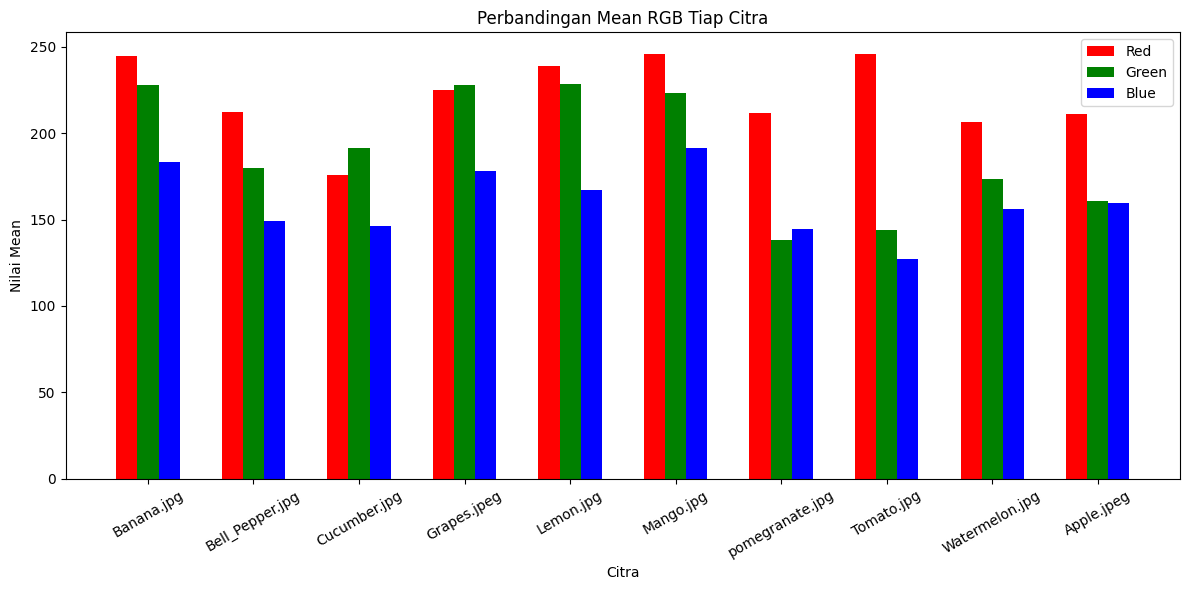

In [55]:
plt.figure(figsize=(12,6))

df['label'] = df['nama_file']

x = np.arange(len(df))

plt.bar(x - 0.2, df['mean_r'], width=0.2, label='Red', color='red')
plt.bar(x, df['mean_g'], width=0.2, label='Green', color='green')
plt.bar(x + 0.2, df['mean_b'], width=0.2, label='Blue', color='blue')

plt.xticks(x, df['label'], rotation=30)
plt.title("Perbandingan Mean RGB Tiap Citra")
plt.xlabel("Citra")
plt.ylabel("Nilai Mean")
plt.legend()

plt.tight_layout()
plt.show()

### **Sebaran Warna (Red VS Green)**
Grafik dibawah ini menunjukkan hubungan antara nilai mean warna merah dan hijau, sehingga dapat dilihat sebaran dan kemiripan warna antar citra.

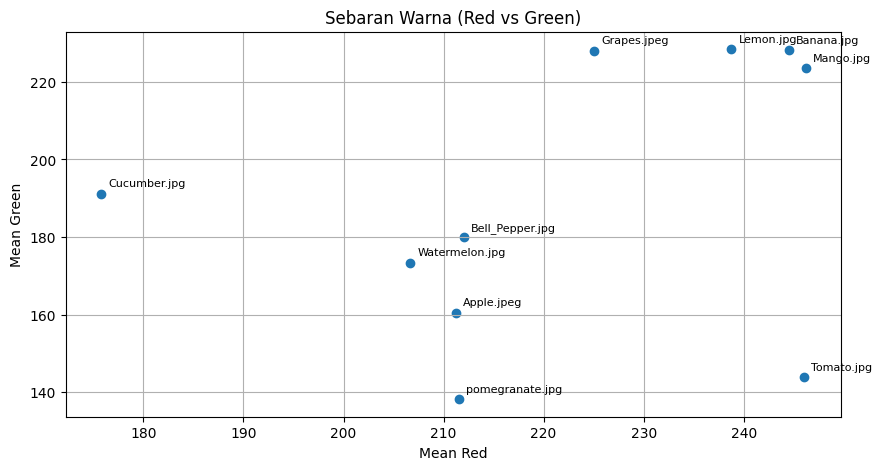

In [43]:
plt.figure(figsize=(10,5))

plt.scatter(df['mean_r'], df['mean_g'])

for i, txt in enumerate(df['nama_file']):
    plt.annotate(txt,
                 (df['mean_r'][i], df['mean_g'][i]),
                 xytext=(5,5),  # geser posisi teks
                 textcoords='offset points',
                 fontsize=8)

plt.title("Sebaran Warna (Red vs Green)")
plt.xlabel("Mean Red")
plt.ylabel("Mean Green")
plt.grid()
plt.show()

### **Distribusi Warna**
Grafik dibawah ini menunjukkan distribusi nilai RGB pada dataset, sehingga dapat diketahui warna yang paling dominan muncul pada citra buah dan sayuran.

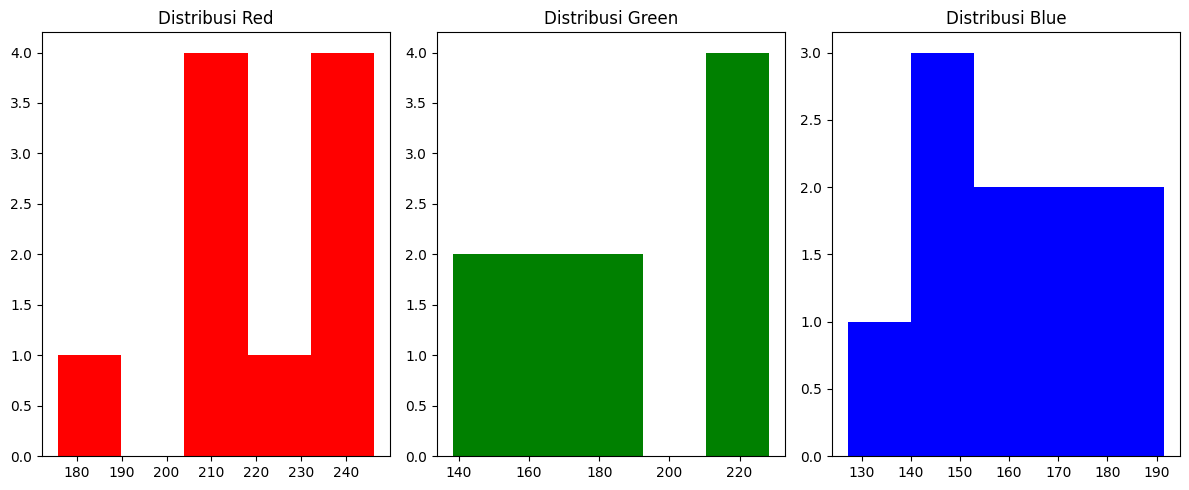

In [57]:
plt.figure(figsize=(12,5))

plt.subplot(1,3,1)
plt.hist(df['mean_r'], bins=5, color='red')
plt.title("Distribusi Red")

plt.subplot(1,3,2)
plt.hist(df['mean_g'], bins=5, color='green')
plt.title("Distribusi Green")

plt.subplot(1,3,3)
plt.hist(df['mean_b'], bins=5, color='blue')
plt.title("Distribusi Blue")

plt.tight_layout()
plt.show()